##### ARTI 560 - Computer Vision

## Instance Segmentation - Exercise 

### Objective

In this exercise, you will implement **Instance Object Segmentation** using a pretrained **Mask R-CNN model** from TensorFlow Hub.

You will follow these steps:

1. **Load the pretrained Mask R-CNN model**  
   - Use this Kaggle link: [Mask R-CNN Inception-ResNet-v2](https://www.kaggle.com/models/tensorflow/mask-rcnn-inception-resnet-v2)  

2. **Select and load 5 different images**  
   - Choose **5 diverse images**, including:  
      - Crowded scenes with multiple objects  
      - Unusual angles, lighting conditions, or occlusions  
      - At least **one image containing multiple objects of the same class** 

3. **Perform inference using the model**  
   - Feed images to the model to obtain predictions  

4. **Extract prediction outputs**  
   - **Bounding boxes** – coordinates of detected objects  
   - **Class labels** – names of detected objects  
   - **Segmentation masks** – pixel-wise masks for each object  

5. **Visualize the results**  
   - Overlay masks on detected objects  
   - Draw bounding boxes around objects  
   - Display class names and confidence scores  

6. **Experiment with confidence thresholds**  
   - Default threshold: **0.5**  
   - Lower threshold: **0.3** to detect more objects (may include false positives)  

---

- Keep in mind:  
  - Some objects may not be recognized at the default threshold 
  - The model only detects objects from the **COCO dataset (80 classes)**  


In [11]:
!pip install tensorflow tensorflow-hub opencv-python matplotlib pillow

import tensorflow as tf
import tensorflow_hub as hub
import numpy as np
import cv2
import matplotlib.patches as patches
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
model = hub.load("https://tfhub.dev/tensorflow/mask_rcnn/inception_resnet_v2_1024x1024/1")
print("Model loaded successfully!")

Model loaded successfully!


In [3]:
image_paths = ['cats.jpg', 
               'people by big ben.jpeg',
               'persons and bicycle.png',
               'persons with cell phones.png',
               'pizza.png']

def load_image(path):
    img = Image.open(path).convert("RGB") 
    img = np.array(img)
    return img

images = [load_image(p) for p in image_paths]

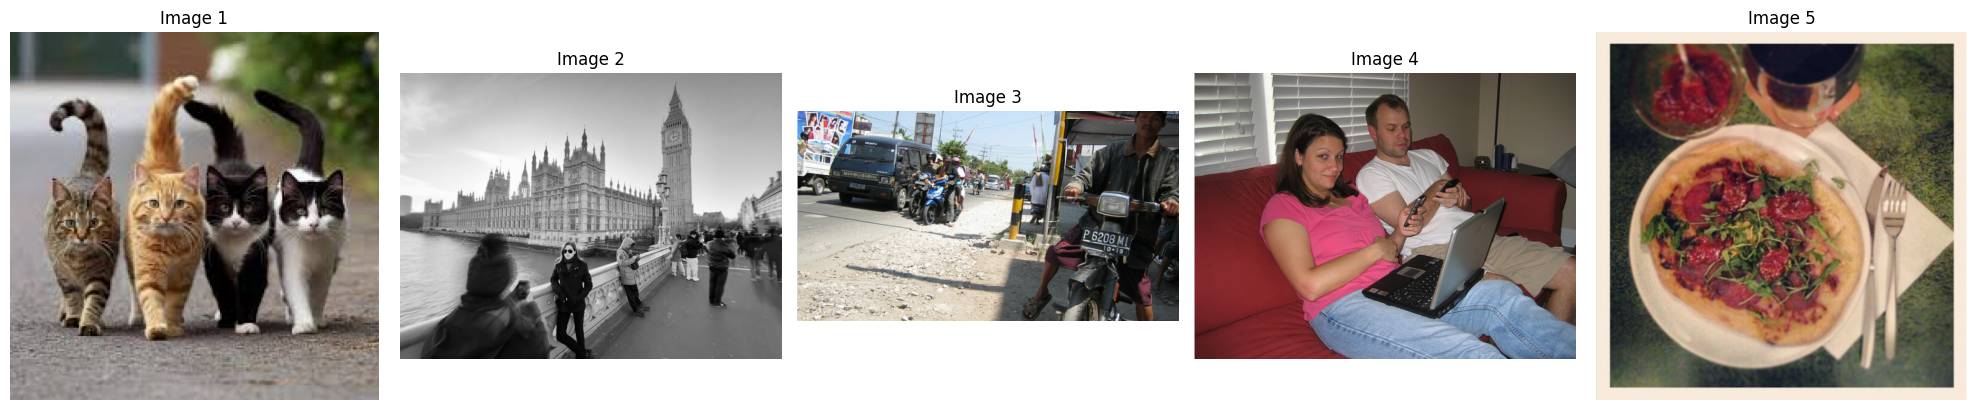

In [4]:
def display_images_row(images):
    n = len(images)

    plt.figure(figsize=(4*n, 4))  # width scales with number of images

    for i, img in enumerate(images):
        plt.subplot(1, n, i+1)  # 1 row, n columns
        plt.imshow(img)
        plt.title(f"Image {i+1}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()
display_images_row(images)

In [5]:
COCO_LABELS = {
    1: 'person', 2: 'bicycle', 3: 'car', 4: 'motorcycle', 5: 'airplane',
    6: 'bus', 7: 'train', 8: 'truck', 9: 'boat', 10: 'traffic light',
    11: 'fire hydrant', 13: 'stop sign', 14: 'parking meter', 15: 'bench',
    16: 'bird', 17: 'cat', 18: 'dog', 19: 'horse', 20: 'sheep', 21: 'cow',
    22: 'elephant', 23: 'bear', 24: 'zebra', 25: 'giraffe', 27: 'backpack',
    28: 'umbrella', 31: 'handbag', 32: 'tie', 33: 'suitcase', 34: 'frisbee',
    35: 'skis', 36: 'snowboard', 37: 'sports ball', 38: 'kite', 39: 'baseball bat',
    40: 'baseball glove', 41: 'skateboard', 42: 'surfboard', 43: 'tennis racket',
    44: 'bottle', 46: 'wine glass', 47: 'cup', 48: 'fork', 49: 'knife', 50: 'spoon',
    51: 'bowl', 52: 'banana', 53: 'apple', 54: 'sandwich', 55: 'orange',
    56: 'broccoli', 57: 'carrot', 58: 'hot dog', 59: 'pizza', 60: 'donut',
    61: 'cake', 62: 'chair', 63: 'couch', 64: 'potted plant', 65: 'bed',
    67: 'dining table', 70: 'toilet', 72: 'tv', 73: 'laptop', 74: 'mouse',
    75: 'remote', 76: 'keyboard', 77: 'cell phone', 78: 'microwave', 79: 'oven',
    80: 'toaster', 81: 'sink', 82: 'refrigerator', 84: 'book', 85: 'clock',
    86: 'vase', 87: 'scissors', 88: 'teddy bear', 89: 'hair drier', 90: 'toothbrush'
}

In [6]:
def run_inference(image):
    if image.shape[-1] == 4:
        image = image[:, :, :3]

    input_tensor = tf.convert_to_tensor(image, dtype=tf.uint8)
    input_tensor = input_tensor[tf.newaxis, ...]

    outputs = model(input_tensor)

    result = {key: value.numpy() for key, value in outputs.items()}
    return result

In [12]:
def visualize_predictions(img, outputs, threshold=0.5, mask_threshold=0.5):

    img_np = img.astype(np.uint8).copy()
    h, w, _ = img_np.shape

    fig, ax = plt.subplots(1, figsize=(12, 8))

    class_ids = outputs["detection_classes"][0].astype(int)
    boxes = outputs["detection_boxes"][0]
    scores = outputs["detection_scores"][0]
    masks = outputs["detection_masks"][0]

    used_text_positions = []

    for i in range(len(scores)):
        if scores[i] < threshold:
            continue

        y1, x1, y2, x2 = boxes[i]

        x1 = int(x1 * w)
        x2 = int(x2 * w)
        y1 = int(y1 * h)
        y2 = int(y2 * h)

        if x2 <= x1 or y2 <= y1:
            continue

        label = COCO_LABELS.get(class_ids[i], "N/A")

        mask = masks[i]
        mask = cv2.resize(mask, (x2 - x1, y2 - y1))
        mask = mask > mask_threshold

        region = img_np[y1:y2, x1:x2].copy()

        color = np.random.randint(0, 256, size=3, dtype=np.uint8)
        region[mask] = (0.7 * region[mask] + 0.3 * color).astype(np.uint8)

        img_np[y1:y2, x1:x2] = region

        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2, edgecolor='red', facecolor='none'
        )
        ax.add_patch(rect)

        text_x = x1
        text_y = max(y1 - 5, 10)

        for prev_x, prev_y in used_text_positions:
            if abs(text_x - prev_x) < 60 and abs(text_y - prev_y) < 20:
                text_y += 20

        used_text_positions.append((text_x, text_y))

        ax.text(
            text_x, text_y,
            f"{label}: {scores[i]:.2f}",
            color='white',
            fontsize=10,
            bbox=dict(facecolor='red', alpha=0.6, edgecolor='none')
        )

    ax.imshow(img_np)
    ax.axis("off")
    plt.show()

Image 1


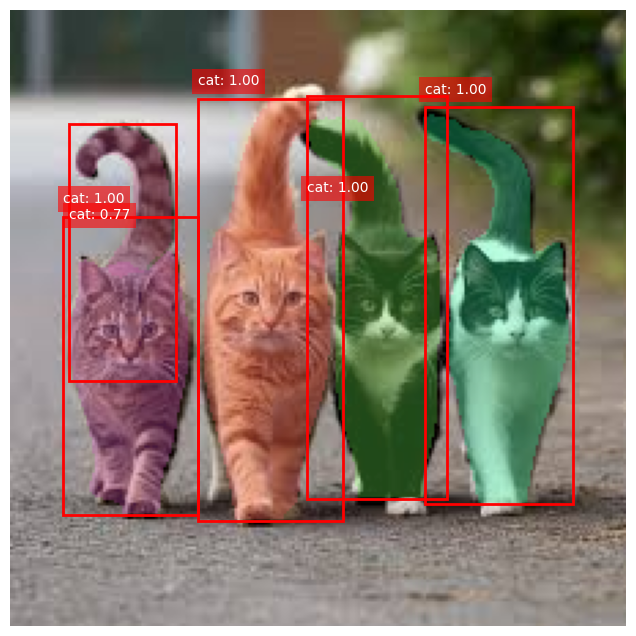

Image 2


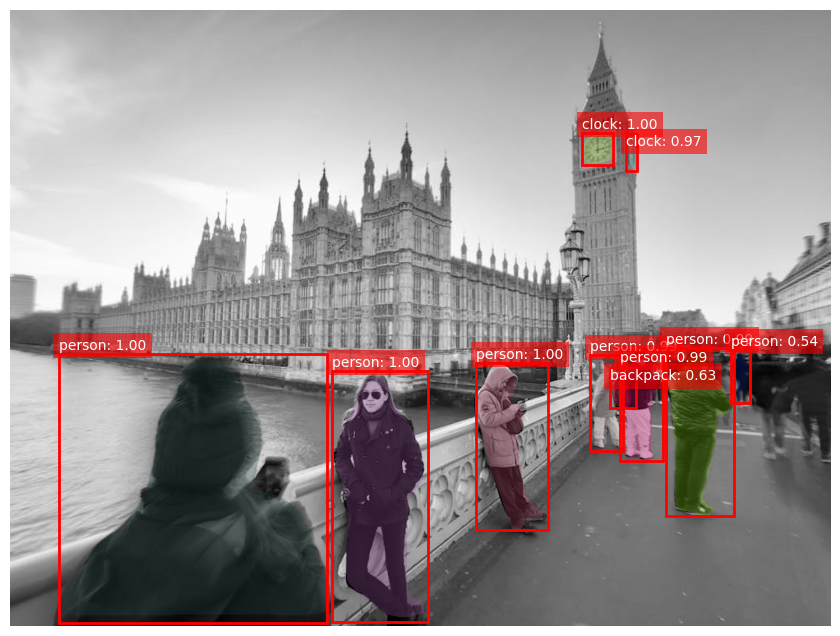

Image 3


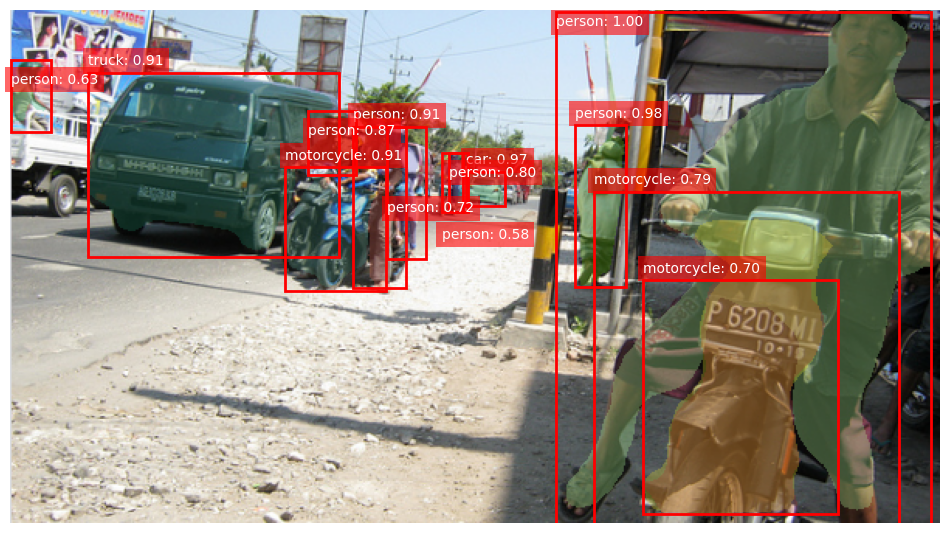

Image 4


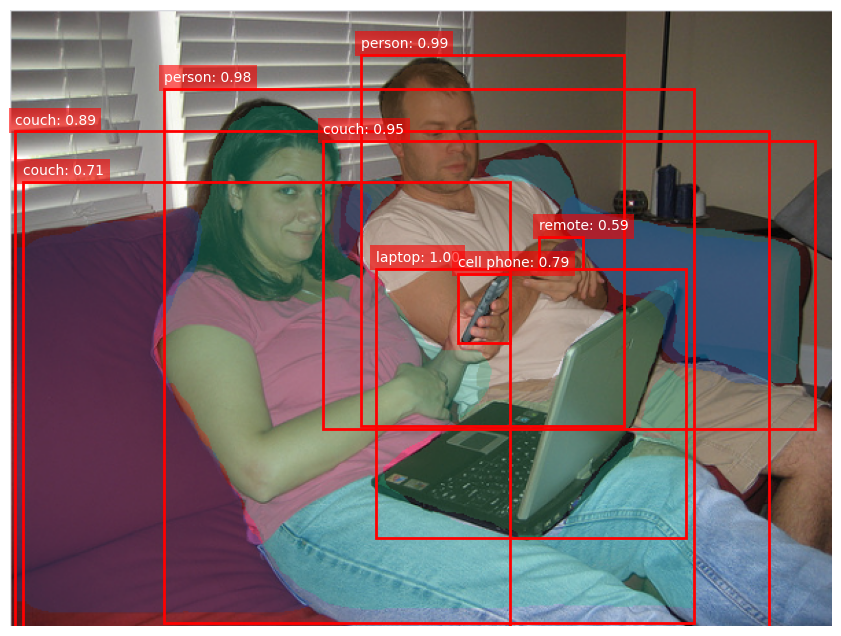

Image 5


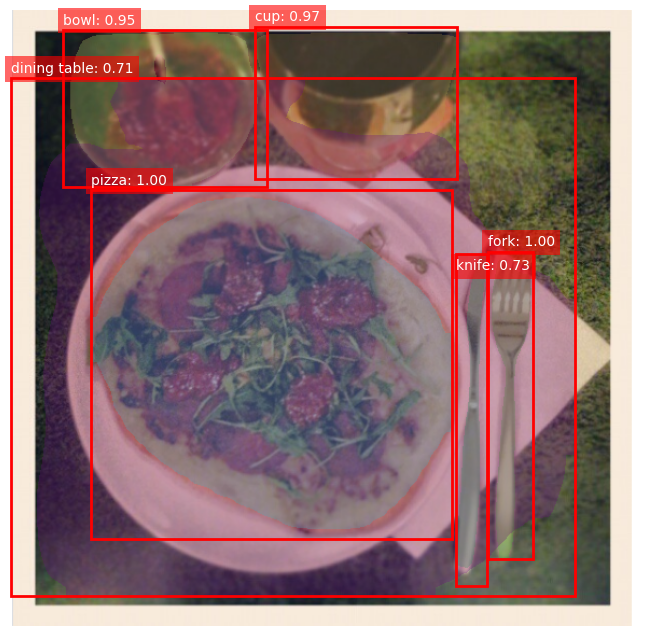

In [13]:
for i, img in enumerate(images):
    outputs = run_inference(img)
    print(f"Image {i+1}")
    visualize_predictions(img, outputs, threshold=0.5, mask_threshold=0.5)

Image 1


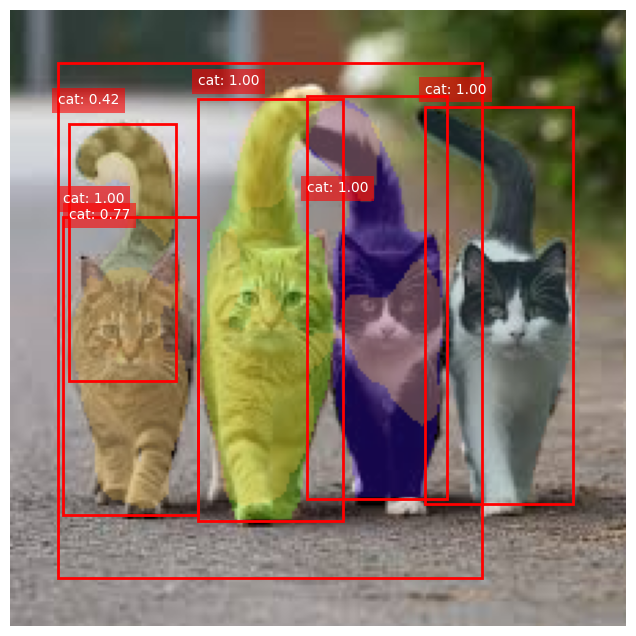

Image 2


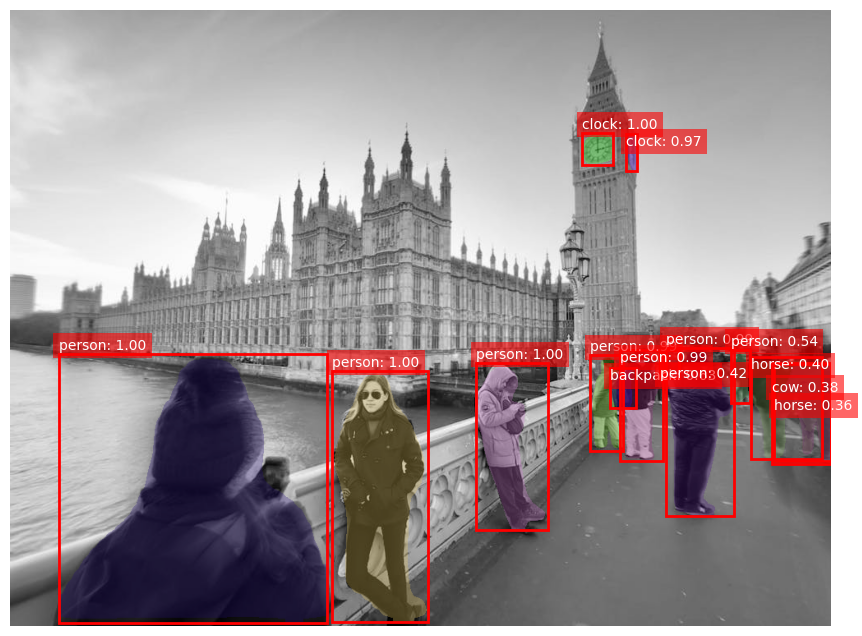

Image 3


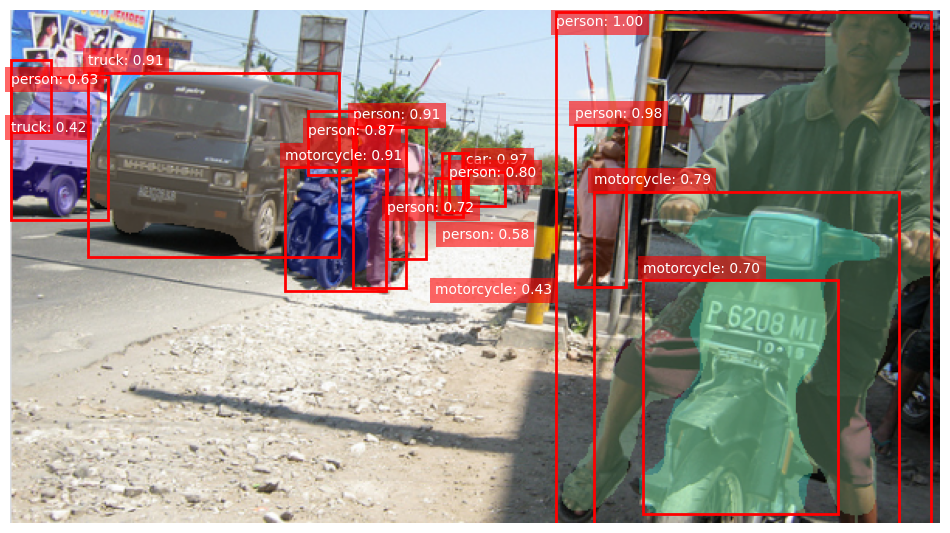

Image 4


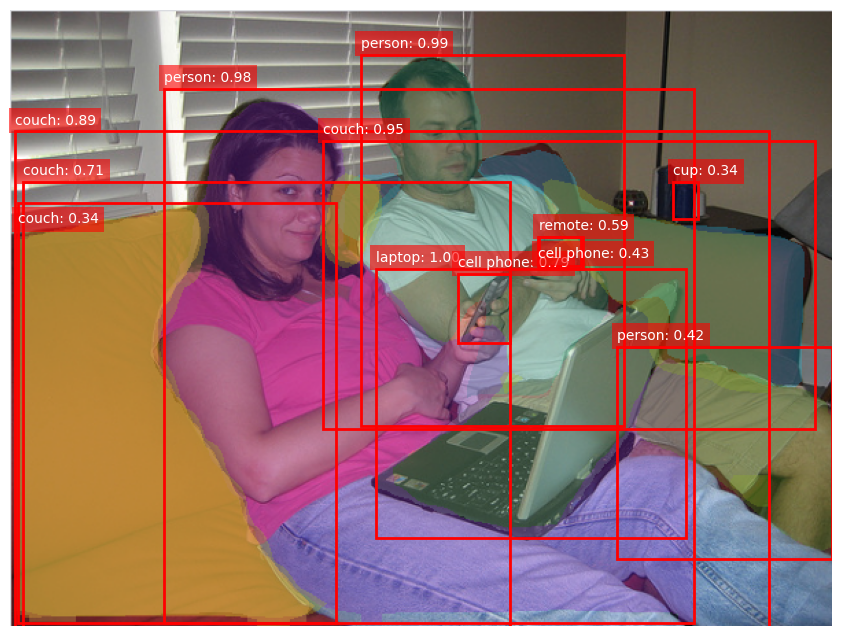

Image 5


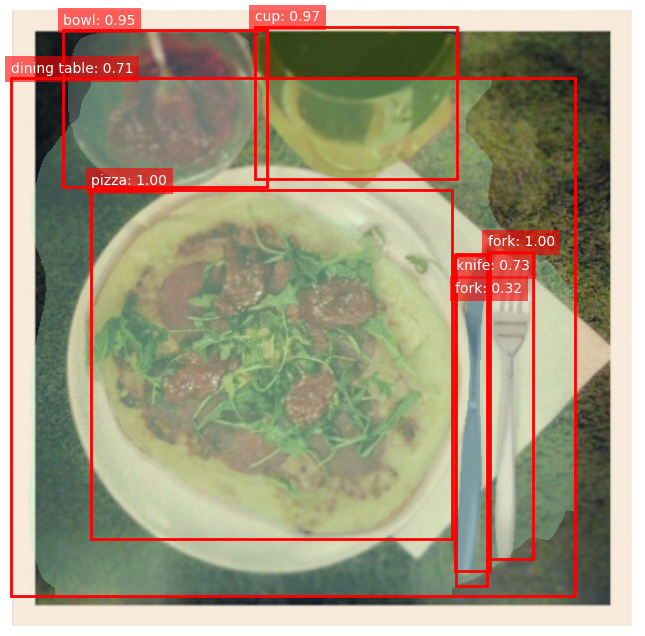

In [14]:
for i, img in enumerate(images):
    outputs = run_inference(img)
    print(f"Image {i+1}")
    visualize_predictions(img, outputs, threshold=0.3, mask_threshold=0.3)